# Exploratory Data Analysis

Now that we completed our cleaning, we'll move onto analysis. This notebook explores our cleaned and merged dataset to understand:
1. The distribution of variables across states
2. Which states rank highest/lowest on digital infrastructure and healthcare engagement
3. Initial relationships between digital access and healthcare utilization
4. Data quality and outliers

## Setup

Let's start by loading our needed libraries and our merged dataset from the cleaning.

In [1]:
import os
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import config

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load merged data
merged_data = pd.read_csv('../data/processed/merged_brfss_ntia.csv')

print(f"Dataset shape: {merged_data.shape}")
print(f"Years: {sorted(merged_data['YEAR'].unique())}")
print(f"States: {merged_data['state_abbr'].nunique()}")
print(f"\nColumns:")
print(merged_data.columns.tolist())

Dataset shape: (146, 15)
Years: [2019, 2021, 2023]
States: 50

Columns:
['_STATE', 'YEAR', 'CHECKUP1_pct', 'PERSDOC3_pct', 'FLUSHOT7_pct', 'EXERANY2_pct', 'CHOLCHK3_pct', 'state_abbr', 'callConfUser', 'emailUser', 'homeInternetUser', 'mobilePhoneUser', 'pcOrTabletUser', 'tooExpensiveMainReason', 'wiredHighSpeedAtHome']


First, let's examine our merged dataset a bit and get an overview of what we're working with.

In [2]:
# Display first few rows
print("First 10 rows of merged data:")
print(merged_data.head(10))

print("\n" + "="*80)
print("\nData types:")
print(merged_data.dtypes)

print("\n" + "="*80)
print("\nBasic info:")
print(merged_data.info())

First 10 rows of merged data:
   _STATE  YEAR  CHECKUP1_pct  PERSDOC3_pct  FLUSHOT7_pct  EXERANY2_pct  \
0     1.0  2019     88.992649     84.503681     42.110105     68.509288   
1     2.0  2019     84.432718     86.485489     37.404860     78.318683   
2     4.0  2019     86.371703     91.832503     39.609999     75.933467   
3     5.0  2019     90.143892     92.558563     42.089533     68.765783   
4     6.0  2019     83.203733     87.662391     41.406529     77.586258   
5     8.0  2019     83.037797     89.702631     46.413353     81.322121   
6    10.0  2019     90.104923     87.948642     43.780369     73.378165   
7    11.0  2019     85.146768     89.468512     48.382162     81.018261   
8    12.0  2019     89.170983     88.197207     36.899679     73.522380   
9    13.0  2019     88.948109     85.136507     36.204520     72.142215   

   CHOLCHK3_pct state_abbr  callConfUser  emailUser  homeInternetUser  \
0      8.495179         AL      0.437618   0.884714          0.761154  

## Summary Statistics

We're able to see our variables of interest. Let's calculate the summary statistics for all variables to understand their central tendencies, spread, and ranges.

In [3]:
# Separate healthcare and digital infrastructure variables
healthcare_vars = ['CHECKUP1_pct', 'PERSDOC3_pct', 'FLUSHOT7_pct', 'EXERANY2_pct', 'CHOLCHK3_pct']
digital_vars = ['callConfUser', 'emailUser', 'homeInternetUser', 'mobilePhoneUser', 
                'pcOrTabletUser', 'tooExpensiveMainReason', 'wiredHighSpeedAtHome']

print("="*80)
print("HEALTHCARE ENGAGEMENT VARIABLES (percentages)")
print("="*80)
print(merged_data[healthcare_vars].describe())

print("\n" + "="*80)
print("DIGITAL INFRASTRUCTURE VARIABLES (proportions)")
print("="*80)
print(merged_data[digital_vars].describe())

HEALTHCARE ENGAGEMENT VARIABLES (percentages)
       CHECKUP1_pct  PERSDOC3_pct  FLUSHOT7_pct  EXERANY2_pct  CHOLCHK3_pct
count    146.000000    146.000000    146.000000    146.000000    146.000000
mean      86.829406     74.510164     44.124475     75.317250     12.748179
std        2.924985     12.775201      5.262493      4.207058      3.787904
min       76.380861     53.391386     32.078537     62.260296      6.928926
25%       85.321071     64.271263     40.103122     72.925741     10.066859
50%       87.398052     70.049017     43.861877     75.358308     12.263314
75%       89.030813     89.037852     48.069046     78.316219     14.840456
max       91.938078     96.466323     57.220469     84.822931     35.763636

DIGITAL INFRASTRUCTURE VARIABLES (proportions)
       callConfUser   emailUser  homeInternetUser  mobilePhoneUser  \
count    146.000000  146.000000        146.000000       146.000000   
mean       0.603027    0.916051          0.794812         0.785280   
std        0

## Histogram Visualization

Great, from the descriptive statistics above we see:
- **Healthcare engagement** is generally high across states: 87% average for routine checkups, 75% for having a personal doctor, but only 44% for flu shots and 13% for recent cholesterol checks

- **Digital infrastructure** shows strong adoption: 92% email use, 79% home internet, but only 60% video calling capability and 69% PC/tablet ownership

- **Cost barriers** affect only 3% on average, but this ranges from 2% to 6% across states

Now let's visualize these distributions to identify any patterns, skewness, or outliers.

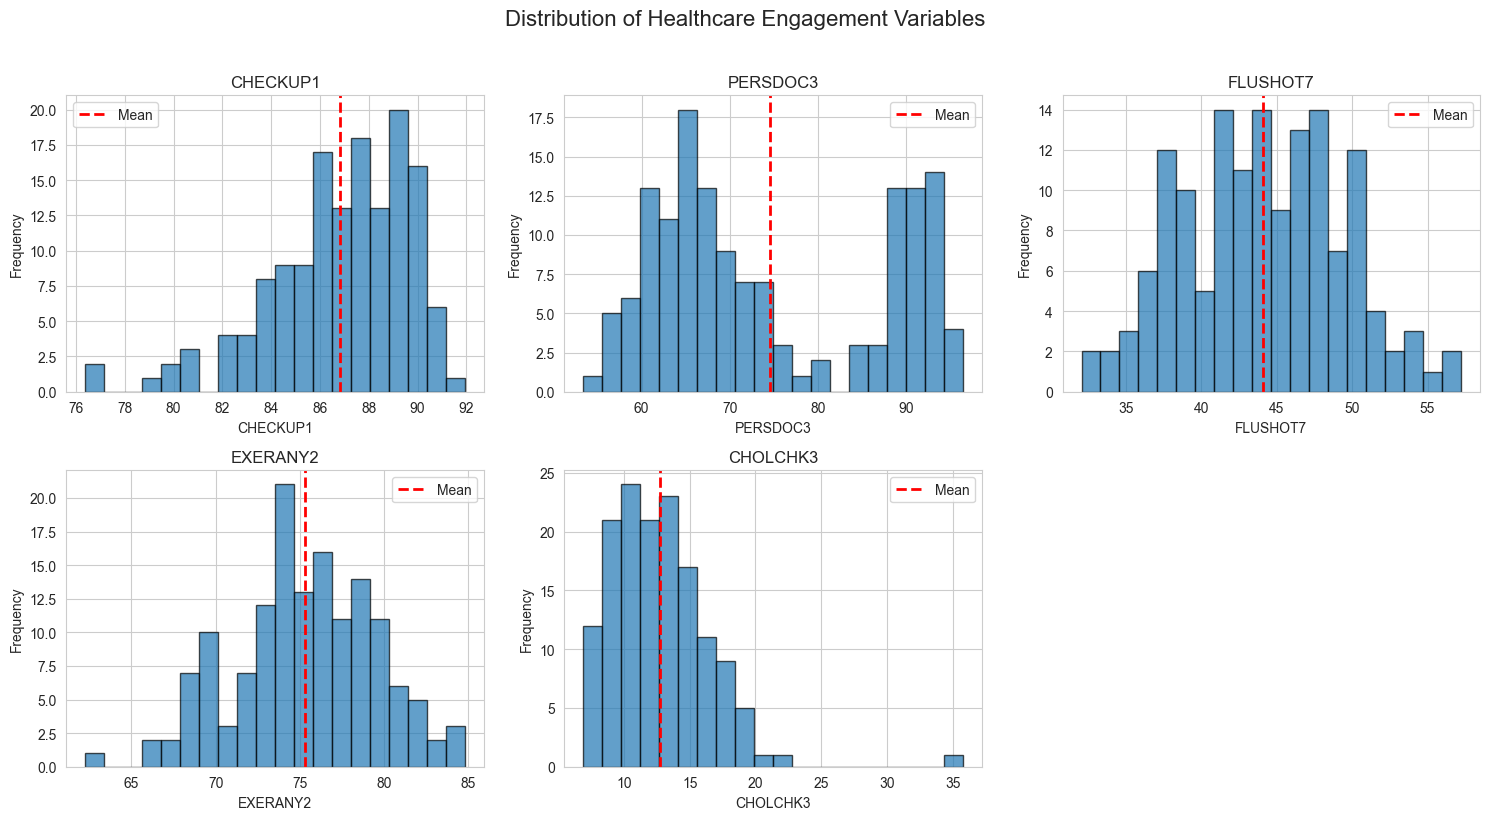

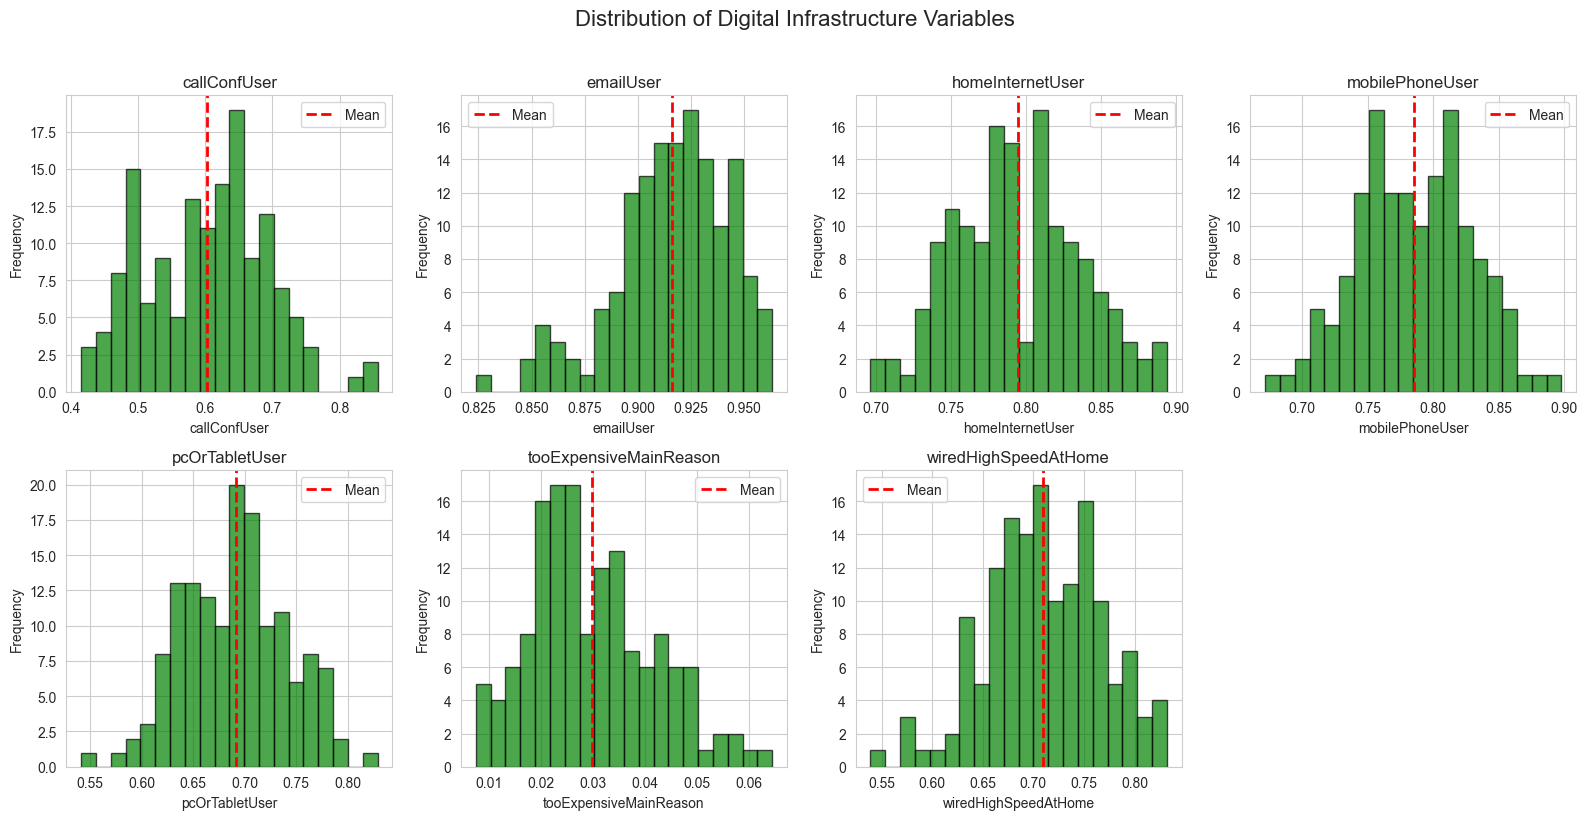

In [4]:
# Create figure with subplots for healthcare variables
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution of Healthcare Engagement Variables', fontsize=16, y=1.02)

for idx, var in enumerate(healthcare_vars):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    ax.hist(merged_data[var], bins=20, edgecolor='black', alpha=0.7)
    ax.set_xlabel(var.replace('_pct', ''))
    ax.set_ylabel('Frequency')
    ax.set_title(var.replace('_pct', ''))
    ax.axvline(merged_data[var].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    ax.legend()

# Remove empty subplot
fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

# Create figure for digital infrastructure variables
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribution of Digital Infrastructure Variables', fontsize=16, y=1.02)

for idx, var in enumerate(digital_vars):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    
    ax.hist(merged_data[var], bins=20, edgecolor='black', alpha=0.7, color='green')
    ax.set_xlabel(var)
    ax.set_ylabel('Frequency')
    ax.set_title(var)
    ax.axvline(merged_data[var].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    ax.legend()

# Remove empty subplot
fig.delaxes(axes[1, 3])
plt.tight_layout()
plt.show()

Looking at the histograms above:

**Healthcare Engagement:**

- **CHECKUP1** (routine checkups): Roughly normal distribution around 87%, most states cluster between 85-90%

- **PERSDOC3** (personal doctor): **Bimodal distribution** - two peaks that some states cluster around 65-70%, others around 85-95%, suggesting two distinct groups

- **FLUSHOT7** (flu shots): Normal distribution around 44%, relatively consistent across states

- **CHOLCHK3** (cholesterol checks): Right-skewed with one clear outlier around 35% (most states 8-15%)


**Digital Infrastructure:**

- Most variables show roughly **normal distributions** 

- **Email use** is highest and most consistent (92% average, tight clustering)

- **Video calling capability** shows widest variation (42% to 86%)

- **Cost barriers** are right-skewed - most states have low barriers (2-3%), but some reach 6%

The bimodal distribution in personal doctor access and the outlier in cholesterol checks tell us we need to investigate this further.

## State Rankings

Okay, now let's see which states rank highest and lowest on key variables to understand geographic patterns.

In [5]:
# Top and bottom 5 states for healthcare engagement (average across all healthcare vars)
merged_data['healthcare_avg'] = merged_data[healthcare_vars].mean(axis=1)
merged_data['digital_avg'] = merged_data[digital_vars].mean(axis=1)

print("="*80)
print("TOP 5 STATES: Healthcare Engagement (averaged across all healthcare variables)")
print("="*80)
top_health = merged_data.nlargest(5, 'healthcare_avg')[['state_abbr', 'YEAR', 'healthcare_avg'] + healthcare_vars]
print(top_health.to_string())

print("\n" + "="*80)
print("BOTTOM 5 STATES: Healthcare Engagement")
print("="*80)
bottom_health = merged_data.nsmallest(5, 'healthcare_avg')[['state_abbr', 'YEAR', 'healthcare_avg'] + healthcare_vars]
print(bottom_health.to_string())

print("\n" + "="*80)
print("TOP 5 STATES: Digital Infrastructure (averaged across all digital variables)")
print("="*80)
top_digital = merged_data.nlargest(5, 'digital_avg')[['state_abbr', 'YEAR', 'digital_avg'] + digital_vars]
print(top_digital.to_string())

print("\n" + "="*80)
print("BOTTOM 5 STATES: Digital Infrastructure")
print("="*80)
bottom_digital = merged_data.nsmallest(5, 'digital_avg')[['state_abbr', 'YEAR', 'digital_avg'] + digital_vars]
print(bottom_digital.to_string())

TOP 5 STATES: Healthcare Engagement (averaged across all healthcare variables)
   state_abbr  YEAR  healthcare_avg  CHECKUP1_pct  PERSDOC3_pct  FLUSHOT7_pct  EXERANY2_pct  CHOLCHK3_pct
96         WI  2021       65.282944     84.263364     96.466323     50.655054     79.698175     15.331802
43         VT  2019       64.761980     85.269550     95.111898     47.563170     79.999656     15.865626
66         ME  2021       64.621553     87.263613     76.536268     50.042294     73.501956     35.763636
28         NH  2019       64.088502     87.744640     95.777747     47.714085     78.289186     10.916850
45         WA  2019       63.927694     83.389042     91.823772     48.331174     80.816680     15.277804

BOTTOM 5 STATES: Healthcare Engagement
    state_abbr  YEAR  healthcare_avg  CHECKUP1_pct  PERSDOC3_pct  FLUSHOT7_pct  EXERANY2_pct  CHOLCHK3_pct
114         LA  2023       52.747720     90.914039     58.540025     34.859926     69.857041      9.567569
120         MS  2023       52.8

Based on the rankings above, we see clear geographic and demographic patterns:

**Healthcare Engagement:**

- **Top performers**: Wisconsin, Vermont, Maine, New Hampshire, Washington - mix of northern states with strong healthcare systems

- **Bottom performers**: Louisiana, Mississippi, Nevada, Georgia, South Carolina - predominantly southern states

- **Range**: Top states average 63-65%, bottom states 52-54% - a 12 percentage point gap


**Digital Infrastructure:**

- **Top performers**: DC, Washington, Colorado, Utah, New Hampshire - urban centers and educated populations

- **Bottom performers**: West Virginia, North Carolina, Louisiana, Alaska - rural/remote states

- **Range**: Top states 0.73-0.75 (73-75%), bottom 0.57-0.58 (57-58%) - a 16 percentage point gap

**Key finding**: Some overlap exists (WA, NH rank high on both; LA ranks low on both), but it's not perfect. For example, West Virginia has low digital infrastructure but doesn't appear in bottom 5 for healthcare engagement.

## Scatterplot Visualization

Now let's create scatter plots to preview potential relationships between digital infrastructure and healthcare engagement before the formal statistical testing.

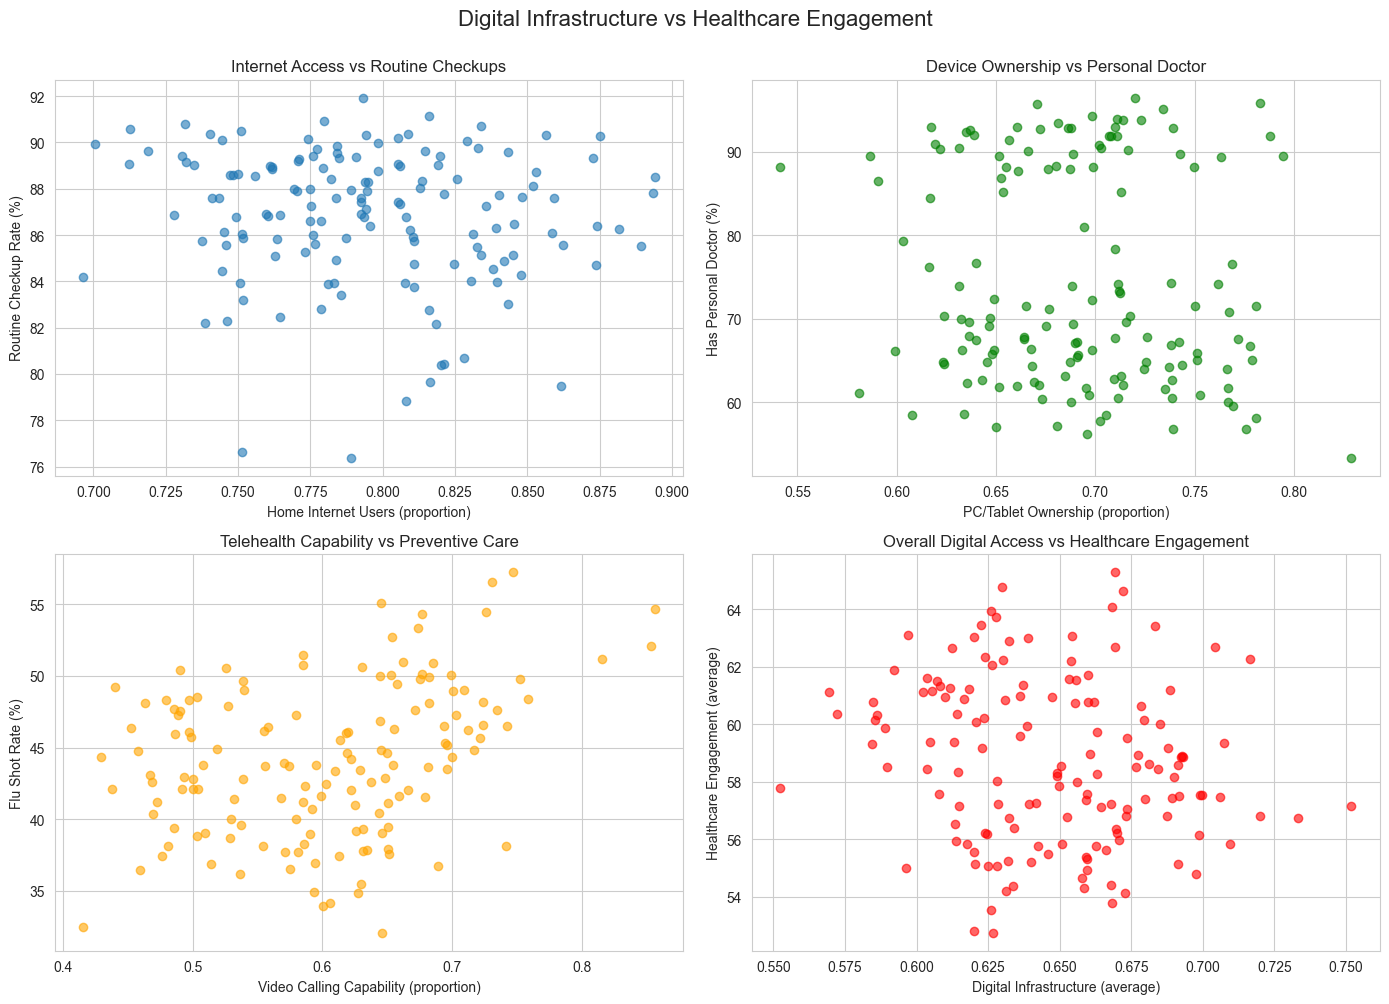

In [6]:
# Create scatter plots for key relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Digital Infrastructure vs Healthcare Engagement', fontsize=16, y=1.00)

# Plot 1: Internet access vs routine checkups
axes[0, 0].scatter(merged_data['homeInternetUser'], merged_data['CHECKUP1_pct'], alpha=0.6)
axes[0, 0].set_xlabel('Home Internet Users (proportion)')
axes[0, 0].set_ylabel('Routine Checkup Rate (%)')
axes[0, 0].set_title('Internet Access vs Routine Checkups')

# Plot 2: PC/Tablet ownership vs personal doctor
axes[0, 1].scatter(merged_data['pcOrTabletUser'], merged_data['PERSDOC3_pct'], alpha=0.6, color='green')
axes[0, 1].set_xlabel('PC/Tablet Ownership (proportion)')
axes[0, 1].set_ylabel('Has Personal Doctor (%)')
axes[0, 1].set_title('Device Ownership vs Personal Doctor')

# Plot 3: Video calling capability vs flu shots
axes[1, 0].scatter(merged_data['callConfUser'], merged_data['FLUSHOT7_pct'], alpha=0.6, color='orange')
axes[1, 0].set_xlabel('Video Calling Capability (proportion)')
axes[1, 0].set_ylabel('Flu Shot Rate (%)')
axes[1, 0].set_title('Telehealth Capability vs Preventive Care')

# Plot 4: Average digital infrastructure vs average healthcare
axes[1, 1].scatter(merged_data['digital_avg'], merged_data['healthcare_avg'], alpha=0.6, color='red')
axes[1, 1].set_xlabel('Digital Infrastructure (average)')
axes[1, 1].set_ylabel('Healthcare Engagement (average)')
axes[1, 1].set_title('Overall Digital Access vs Healthcare Engagement')

plt.tight_layout()
plt.show()

The scatter plots above provide an initial view of the state-level relationships.

**Observed Patterns:**

- **Internet access vs. routine checkups:** No clear linear pattern is visible.
- **PC/tablet use vs. personal doctor access:** Considerable variation is present across observations.
- **Video calling vs. flu shots:** The observations are widely scattered.
- **Overall comparison:** Any visible trend is accompanied by substantial variation.

**Interpretation:** These exploratory plots suggest that digital infrastructure alone does not account for the observed differences in healthcare engagement. Other demographic, socioeconomic, geographic, or temporal factors may also contribute to these state-level patterns.

The next notebook quantifies these associations using correlation analysis, group comparisons, and simple linear regression. These analyses remain observational and are not interpreted causally.

## Identifying Outliers

Let's start with identifying any states that are statistical outliers on key variables.

In [7]:
# Calculate z-scores to identify outliers (|z| > 2.5)
from scipy import stats

# Check for outliers in key variables
outlier_vars = ['CHECKUP1_pct', 'PERSDOC3_pct', 'CHOLCHK3_pct', 'homeInternetUser', 'callConfUser']

print("States with outlier values (|z-score| > 2.5):\n")
for var in outlier_vars:
    z_scores = np.abs(stats.zscore(merged_data[var]))
    outliers = merged_data[z_scores > 2.5][['state_abbr', 'YEAR', var]]
    
    if len(outliers) > 0:
        print(f"\n{var}:")
        print(outliers.to_string(index=False))
    else:
        print(f"\n{var}: No outliers detected")

States with outlier values (|z-score| > 2.5):


CHECKUP1_pct:
state_abbr  YEAR  CHECKUP1_pct
        CA  2021     76.380861
        NM  2021     76.649171
        OR  2021     79.497602
        WA  2021     78.850038

PERSDOC3_pct: No outliers detected

CHOLCHK3_pct:
state_abbr  YEAR  CHOLCHK3_pct
        AK  2021     22.714534
        ME  2021     35.763636

homeInternetUser: No outliers detected

callConfUser:
state_abbr  YEAR  callConfUser
        DC  2021      0.853542
        DC  2023      0.856245


The outlier analysis is revealing:

**Routine Checkups (CHECKUP1_pct):**

- **West Coast states in 2021** (CA, NM, OR, WA) show unusually LOW checkup rates (76-79% vs 87% average)

- **Possible explanation**: COVID-19 impact - these states had stricter pandemic restrictions in 2021, potentially disrupting routine care access?


**Cholesterol Checks (CHOLCHK3_pct):**

- **Maine 2021**: Exceptionally high at 36% (vs 13% average) - unusual outlier

- **Alaska 2021**: Also high at 23%

- **Possible explanation**: State-specific screening initiatives or demographic differences (since they have older populations)


**Video Calling Capability (callConfUser):**

- **DC in both years**: 85-86% vs 60% average

- **Explanation**: Urban, highly educated population with professional jobs requiring video conferencing


These outliers don't appear to be data errors but reflect real geographic and temporal variations worth noting in our analysis.

## Changes Over Time (2019 → 2021 → 2023)

Now let's check if digital infrastructure and healthcare engagement changed across our three survey years.

In [8]:
# Compare means across years
yearly_comparison = merged_data.groupby('YEAR')[healthcare_vars + digital_vars].mean()

print("="*80)
print("CHANGES OVER TIME: Mean values by year")
print("="*80)
print(yearly_comparison.round(2))

# Calculate percent change from 2019 to 2023
change_2019_2023 = ((yearly_comparison.loc[2023] - yearly_comparison.loc[2019]) / yearly_comparison.loc[2019] * 100)

print("\n" + "="*80)
print("PERCENT CHANGE: 2019 → 2023")
print("="*80)
print(change_2019_2023.round(2))

CHANGES OVER TIME: Mean values by year
      CHECKUP1_pct  PERSDOC3_pct  FLUSHOT7_pct  EXERANY2_pct  CHOLCHK3_pct  \
YEAR                                                                         
2019         87.48         90.40         43.68         73.81         11.80   
2021         84.71         69.27         46.03         76.29         14.63   
2023         88.33         63.64         42.64         75.86         11.80   

      callConfUser  emailUser  homeInternetUser  mobilePhoneUser  \
YEAR                                                               
2019          0.50       0.90              0.77             0.76   
2021          0.65       0.92              0.79             0.78   
2023          0.66       0.93              0.82             0.82   

      pcOrTabletUser  tooExpensiveMainReason  wiredHighSpeedAtHome  
YEAR                                                                
2019            0.68                    0.04                  0.69  
2021            0.69  

## Temporal Trends Analysis

The year-over-year comparison shows changes in both digital infrastructure and healthcare measures during the study period.

**Digital Infrastructure**

- **Video calling capability:** 50% → 66% (+16 percentage points)
- **Broadband access:** 69% → 73% (+4 percentage points)
- **Mobile phone use:** 76% → 82% (+6 percentage points)
- **Cost barriers:** 4% → 2% (-2 percentage points)

**Healthcare Engagement**

- **Personal doctor access:** 90% → 64% (-29 percentage points)
- **Routine checkups:** 87% → 88%
- **Exercise:** 74% → 76%
- **Cholesterol checks:** 12% → 12%
- **Flu shots:** 44% → 43%

The large change in personal doctor access warrants caution and further investigation. Potential explanations cannot be determined from this descriptive analysis alone; changes in survey measurement, healthcare delivery, population composition, or other time-varying factors may contribute.

Because 2019–2023 includes the COVID-19 period, temporal comparisons should not be interpreted as evidence that changes in digital infrastructure caused changes in healthcare engagement.

## Summary: Key EDA Findings

**Distribution Patterns**

- Healthcare measures vary across states, with notable variation in personal doctor access.
- Digital infrastructure measures also vary across states, although email use is relatively high and consistent.

**Geographic Patterns**

- Geographic differences are visible in both healthcare and digital measures.
- These patterns are descriptive and do not establish an urban-rural or regional causal effect.

**Relationship Strength**

- Initial scatter plots show substantial variation in the relationships between digital access and healthcare engagement.
- The exploratory results motivate formal correlation and regression analysis.

**Temporal Trends**

- Several digital infrastructure measures increased over the study period.
- Personal doctor access showed a large change that requires cautious interpretation.
- Other healthcare measures were comparatively stable.

**Next Steps**

Notebook 03 will:

1. Calculate correlation coefficients between selected variables.
2. Create a correlation heatmap.
3. Fit simple linear regression models for selected state-level associations.
4. Compare healthcare measures between higher- and lower-digital-infrastructure groups.
5. Create geographic visualizations.

These analyses are observational and do not establish causation.